In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import phe.paillier as paillier
import time

In [2]:
# Setting the random seed
np.random.seed(42)
rng = np.random.default_rng(42)
def randomizer(n, min_val, max_val):
    values = rng.integers(low = min_val, high = max_val, size = n)
    return values

main_list = randomizer(5, 0, 1000000)
print(main_list[:5])

[ 89250 773956 654571 438878 433015]


In [3]:
def baseline_mean(n, min_val, max_val):
    temp_list = randomizer(n, min_val, max_val).tolist()
    
    t0 = time.perf_counter()
    average = np.mean(temp_list)
    t1 = time.perf_counter()
    
    computation_time = t1 - t0

    return computation_time

n_list = [10, 20, 50, 100, 200, 500, 1000]
# for i in n_list:
#     computation_time = baseline_mean(i, 0, 1000000)
#     print(f"n = {i:4d} | Total Runtime = {computation_time:.6f}s")

In [4]:
public_key, private_key = paillier.generate_paillier_keypair()

In [5]:
def paillier_mean(n, min_val, max_val, public_key, private_key):
    temp_list = randomizer(n, min_val, max_val).tolist()

    t0 = time.perf_counter()
    encrypted_values = []
    for i in temp_list:
        encrypted_values.append(public_key.encrypt(i))
    encrypted_sum = sum(encrypted_values)
    decrypted_sum = private_key.decrypt(encrypted_sum)

    average = decrypted_sum / n
    t1 = time.perf_counter()
    computation_time = t1 - t0

    return computation_time

# for i in n_list:
#     computation_time = paillier_mean(i, 0, 1000000, public_key, private_key)
#     print(f"n = {i:4d} | Total Runtime = {computation_time:.6f}s")

In [6]:
def shamir_share_generator(secret, party_count, threshold, min_val, max_val):
    coeffs = [secret] + rng.integers(low = min_val, high = max_val, size = threshold - 1).tolist()
    shares = []

    for x in range(1, party_count + 1):
        y = sum(coeff * (x ** power) for power, coeff in enumerate(coeffs))
        shares.append((x, y))  # store (party index, share value)
    return shares 

def shamir_reconstruct_secret(shares, threshold):
    secret = 0
    for j, (xj, yj) in enumerate(shares[:threshold]):
        lj = 1
        for m, (xm, _) in enumerate(shares[:threshold]):
            if m != j:
                lj *= xm / (xm - xj)
        secret += yj * lj

    return round(secret) 

# shares = shamir_share_generator(12345, 5, 3, 1, 1000000)
# print(shares)
# secret_reconstructed = shamir_reconstruct_secret(shares, 3)
# print("Reconstructed secret:", secret_reconstructed)

In [9]:
def shamir_mean(n, min_val, max_val, party_count, threshold):
    temp_list = randomizer(n, min_val, max_val).tolist()
    decrypted = []
    t0 = time.perf_counter()
    for i in temp_list:
        shares = shamir_share_generator(i, party_count, threshold, min_val, max_val)
        secret_reconstructed = shamir_reconstruct_secret(shares, threshold)
        decrypted.append(secret_reconstructed)

    average = np.mean(decrypted)
    t1 = time.perf_counter()
    computation_time = t1 - t0

    return computation_time

party_count = 10
threshold = party_count // 2
# for i in n_list:
#     computation_time = shamir_mean(i, 0, 1000000, party_count, threshold)
#     print(f"n = {i:4d} | Total Runtime = {computation_time:.6f}s")

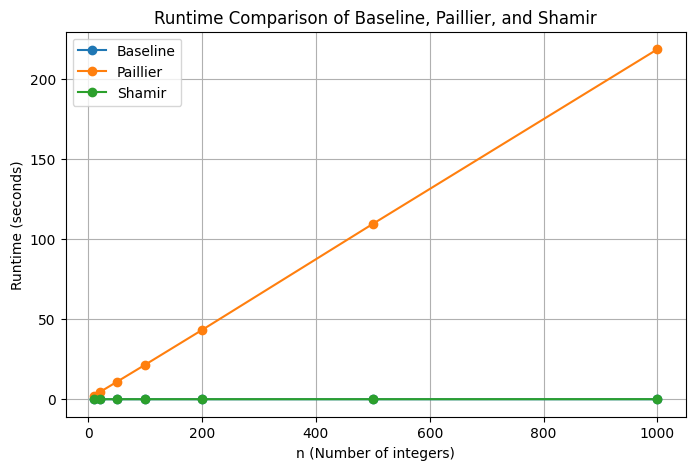

In [ ]:
def full_test(n_list, min_val, max_val, public_key, private_key, party_count, threshold):
    results = []
    for n in n_list:
        # Baseline
        baseline_time = baseline_mean(n, min_val, max_val)

        # Paillier
        paillier_time = paillier_mean(n, min_val, max_val, public_key, private_key)

        # Shamir
        shamir_time = shamir_mean(n, min_val, max_val, party_count, threshold)

        results.append({
            "n": n,
            "Baseline": baseline_time,
            "Paillier": paillier_time,
            "Shamir": shamir_time
        })
    df_results = pd.DataFrame(results)
    return df_results

party_count = 10
threshold = party_count // 2
df_results = full_test(n_list, 0, 1000000, public_key, private_key, party_count, threshold)

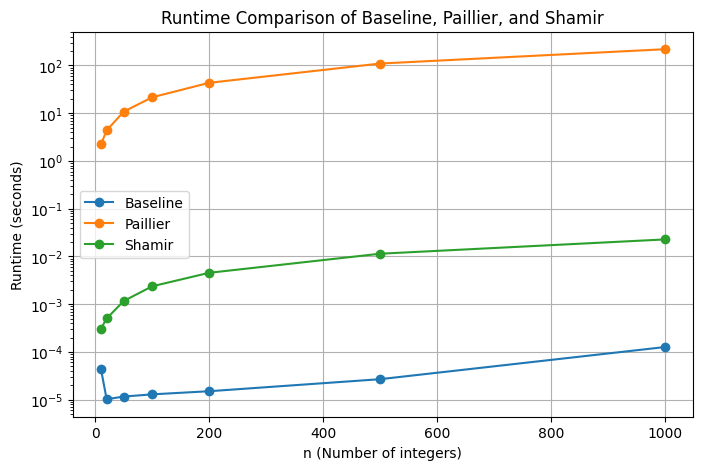

In [ ]:
plt.figure(figsize=(8, 5))
for method in ["Baseline", "Paillier", "Shamir"]:
    plt.plot(df_results["n"], df_results[method], marker='o', label=method)

plt.xlabel("n (Number of integers)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale('log')
plt.title("Runtime Comparison of Baseline, Paillier, and Shamir")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
df_results

,n,Baseline,Paillier,Shamir
0,10,0.000044,2.224883,0.000305
1,20,0.000010,4.357126,0.000501
2,50,0.000012,10.777209,0.001165
3,100,0.000013,21.534350,0.002366
4,200,0.000015,43.272848,0.004536
5,500,0.000027,109.564409,0.011374
6,1000,0.000126,218.737617,0.022668
